**EV CHARGING STATION DEMAND PREDICTION**

Import Libraries

In [1]:
# Step 1 : Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Regression Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


Load Dataset

In [2]:
# Step 2 : Load Dataset

# Load CSV File

df = pd.read_csv("/content/ev_charging_dataset.csv")

# Display First 5 Rows

df.head()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [3]:
df.shape

(8354, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

In [5]:
df.describe()

,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward
count,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,9.526335,61.079722,34.808452,98.495545,39.079746,22.449126,178.700376,4.591573,53.177399,9.959945,0.354101,53.156126,-11.834559
std,4.894049,25.001163,14.478839,3.258039,18.973883,16.813449,149.120567,2.828987,27.380740,2.878798,0.186150,27.563387,9.271940
min,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.000000,0.000000,10.053024,5.000000,0.100157,5.505723,-43.285910
25%,6.000000,40.000000,22.371986,98.463666,23.675251,11.000000,64.118008,3.000000,28.029710,7.510000,0.207315,27.911603,-18.354606
50%,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,133.700252,5.000000,49.421293,9.955000,0.313459,49.513337,-11.268337
75%,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,247.946169,7.000000,77.600445,12.397500,0.462315,77.845036,-5.106912
max,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,776.551110,15.000000,100.000000,15.000000,0.799922,104.985659,14.176434


In [6]:
df.columns

Index(['timestamp', 'station_id', 'location_type', 'vehicle_id',
       'vehicle_type', 'arrival_time', 'charging_start_time',
       'charging_end_time', 'waiting_time', 'battery_capacity_kWh',
       'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW',
       'charging_duration', 'queue_length', 'station_load',
       'electricity_price', 'renewable_energy_ratio', 'traffic_density',
       'weather_condition', 'day_of_week', 'time_slot', 'charging_demand',
       'assigned_charger_id', 'charging_priority', 'optimization_reward'],
      dtype='object')

Data Cleaning

In [7]:
# Step 3 : Data Cleaning

# Check Missing Values
print("Missing Values")
print(df.isnull().sum())

# Total Missing Values
print("\nTotal Missing Values :", df.isnull().sum().sum())

# Check Duplicate Values
print("\nDuplicate Rows :", df.duplicated().sum())

# Remove Duplicate Rows
df = df.drop_duplicates()

# Fill Numerical Missing Values
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill Categorical Missing Values
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check Missing Values Again
print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# Dataset Shape After Cleaning
print("\nDataset Shape After Cleaning :", df.shape)

Missing Values
timestamp                 0
station_id                0
location_type             0
vehicle_id                0
vehicle_type              0
arrival_time              0
charging_start_time       0
charging_end_time         0
waiting_time              0
battery_capacity_kWh      0
initial_soc               0
final_soc                 0
energy_consumed_kWh       0
charging_power_kW         0
charging_duration         0
queue_length              0
station_load              0
electricity_price         0
renewable_energy_ratio    0
traffic_density           0
weather_condition         0
day_of_week               0
time_slot                 0
charging_demand           0
assigned_charger_id       0
charging_priority         0
optimization_reward       0
dtype: int64

Total Missing Values : 0

Duplicate Rows : 0

Missing Values After Cleaning
timestamp                 0
station_id                0
location_type             0
vehicle_id                0
vehicle_type              0

In [8]:
df.dtypes

,0
timestamp,object
station_id,object
location_type,object
vehicle_id,object
vehicle_type,object
arrival_time,object
charging_start_time,object
charging_end_time,object
waiting_time,int64
battery_capacity_kWh,int64


Exploratory Data Analysis (EDA)

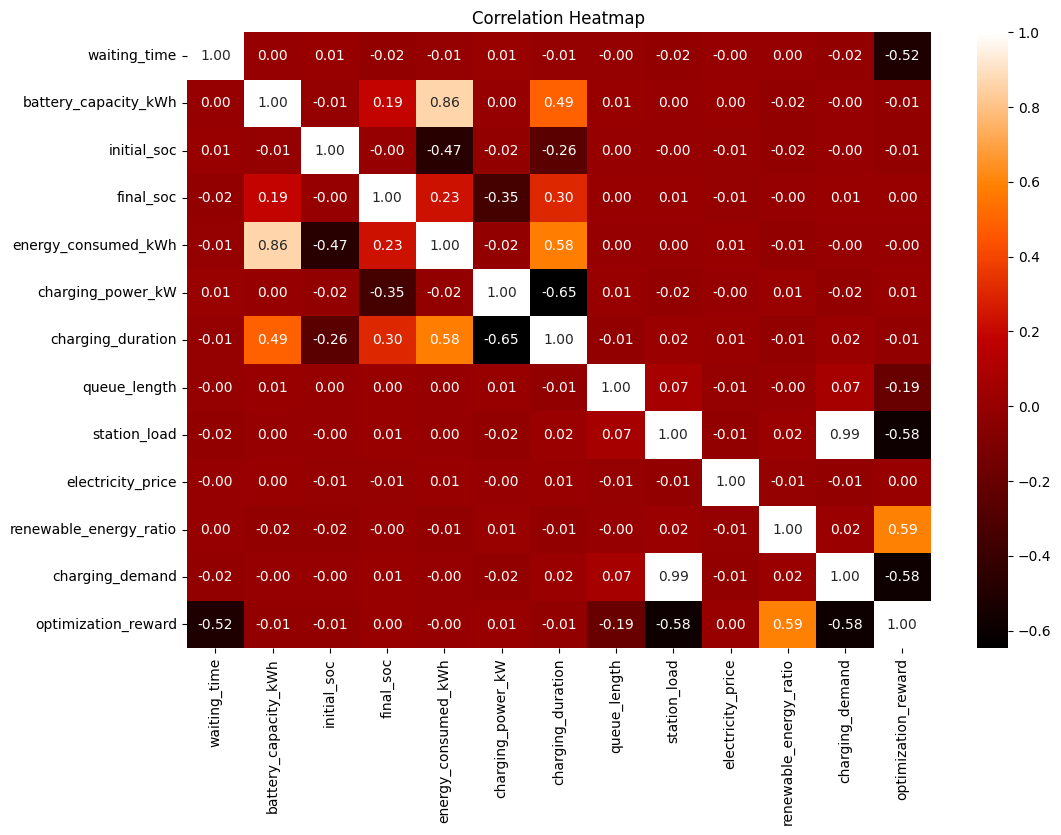

In [9]:
#Step 4: EDA
#Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="gist_heat",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

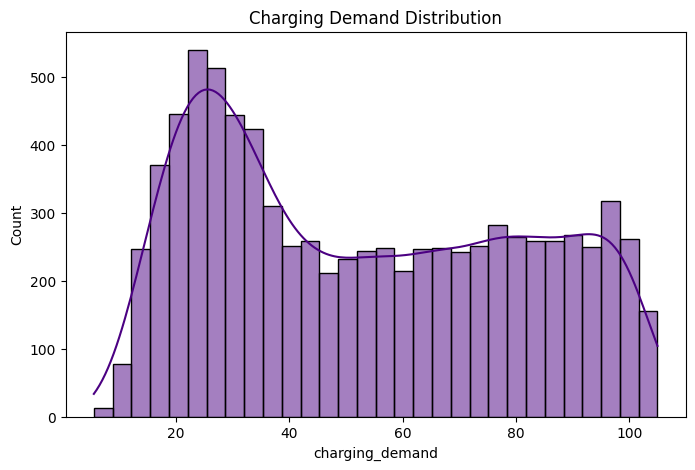

In [10]:
#Target Variable Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["charging_demand"], kde=True, bins=30, color="indigo")
plt.title("Charging Demand Distribution")
plt.show()

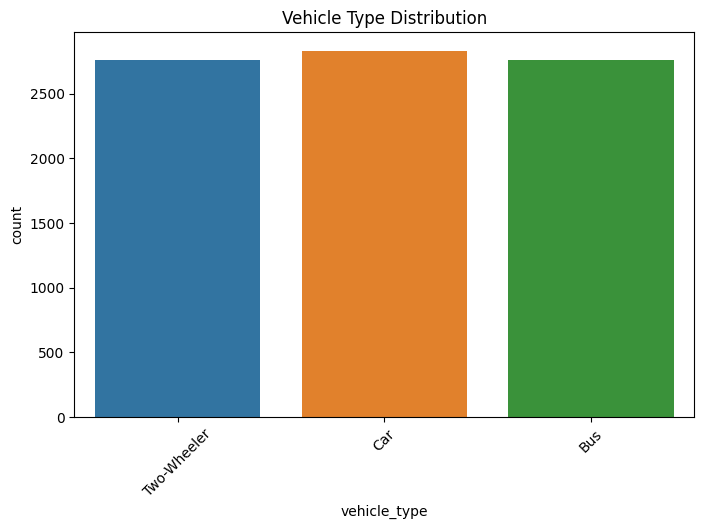

In [11]:
#Vehicle Type Distribution

plt.figure(figsize=(8,5))
sns.countplot(x=df["vehicle_type"], palette="tab10")
plt.xticks(rotation=45)
plt.title("Vehicle Type Distribution")
plt.show()

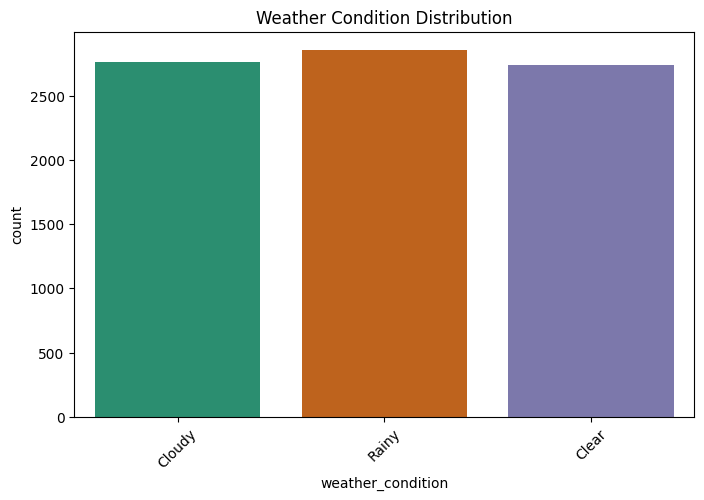

In [12]:
#Weather Condition Distribution

plt.figure(figsize=(8,5))
sns.countplot(x=df["weather_condition"], palette="Dark2")
plt.xticks(rotation=45)
plt.title("Weather Condition Distribution")
plt.show()

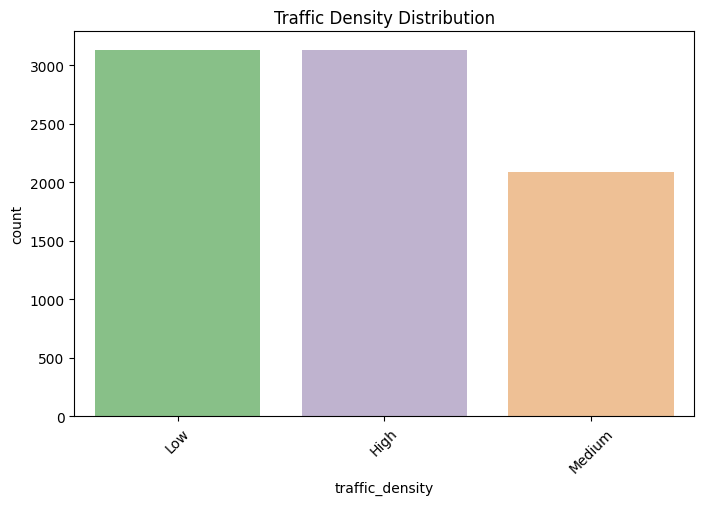

In [13]:
#Traffic Density Distribution

plt.figure(figsize=(8,5))
sns.countplot(x=df["traffic_density"], palette="Accent")
plt.xticks(rotation=45)
plt.title("Traffic Density Distribution")
plt.show()

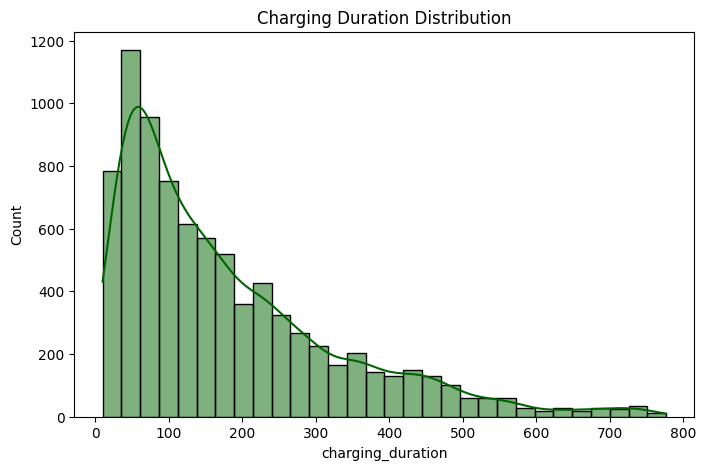

In [14]:
#Charging Duration Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["charging_duration"], kde=True, bins=30, color="Darkgreen")
plt.title("Charging Duration Distribution")
plt.show()

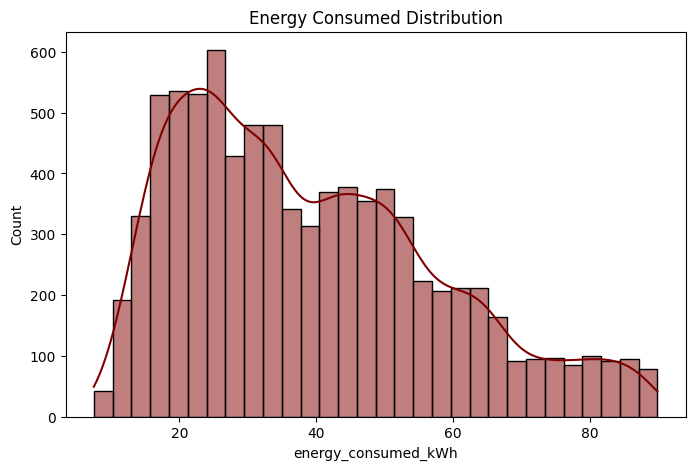

In [15]:
#Energy Consumed Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["energy_consumed_kWh"], kde=True, bins=30, color="Maroon")
plt.title("Energy Consumed Distribution")
plt.show()

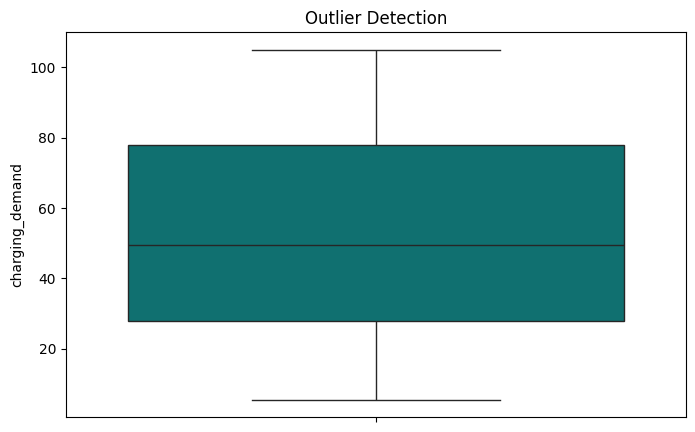

In [16]:
#Boxplot (Outlier Detection)

plt.figure(figsize=(8,5))
sns.boxplot(y=df["charging_demand"], color="teal")
plt.title("Outlier Detection")
plt.show()

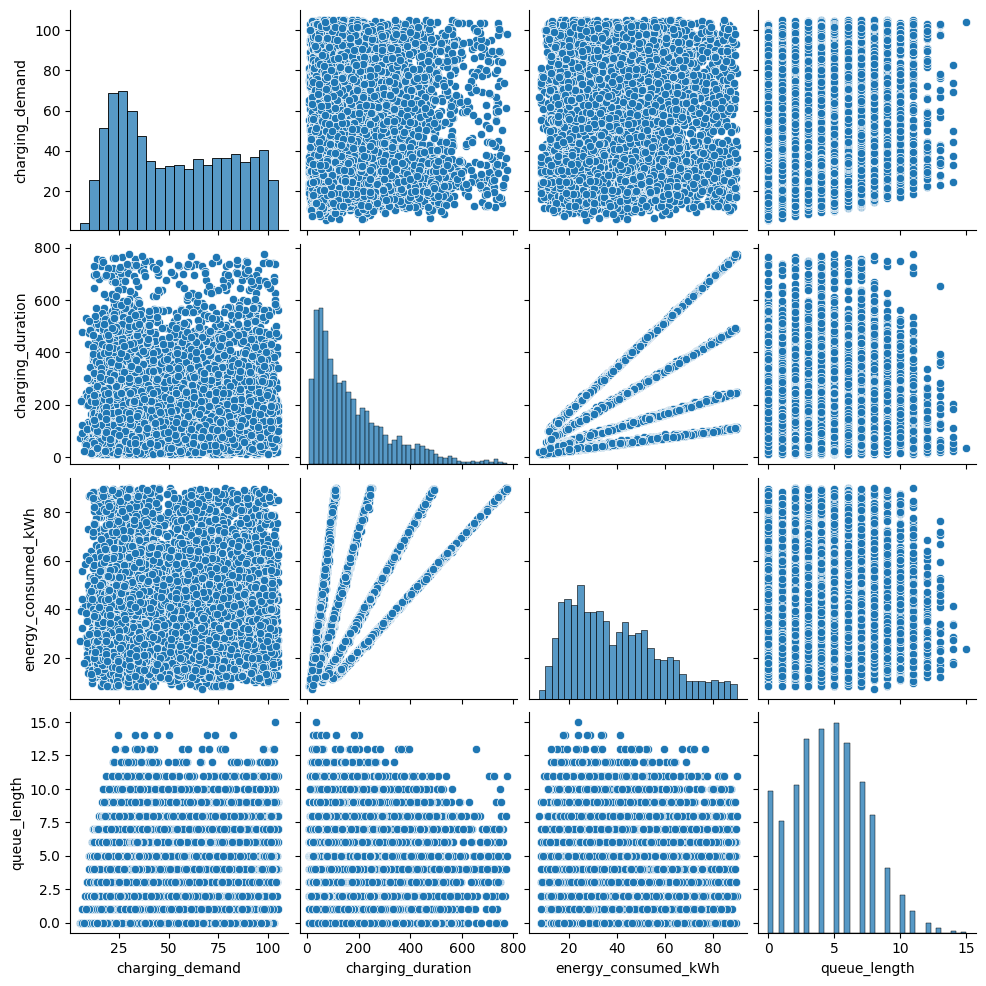

In [17]:
#Pair Plot

sns.pairplot(df[[
    "charging_demand",
    "charging_duration",
    "energy_consumed_kWh",
    "queue_length"
]])
plt.show()

Data Preprocessing

In [18]:
#Check info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

In [19]:
#Check Duplicates Record
df.duplicated().sum()

np.int64(0)

In [20]:
#Separate Numerical & Categorical Columns
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns :", numerical_columns)
print("Categorical Columns :", categorical_columns)

Numerical Columns : Index(['waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc',
       'energy_consumed_kWh', 'charging_power_kW', 'charging_duration',
       'queue_length', 'station_load', 'electricity_price',
       'renewable_energy_ratio', 'charging_demand', 'optimization_reward'],
      dtype='object')
Categorical Columns : Index(['timestamp', 'station_id', 'location_type', 'vehicle_id',
       'vehicle_type', 'arrival_time', 'charging_start_time',
       'charging_end_time', 'traffic_density', 'weather_condition',
       'day_of_week', 'time_slot', 'assigned_charger_id', 'charging_priority'],
      dtype='object')


In [21]:
#Verify Missing Values

df.isnull().sum()

,0
timestamp,0
station_id,0
location_type,0
vehicle_id,0
vehicle_type,0
arrival_time,0
charging_start_time,0
charging_end_time,0
waiting_time,0
battery_capacity_kWh,0


In [22]:
#Encode Categorical Features

from sklearn.preprocessing import LabelEncoder

# Create a dictionary to hold LabelEncoder instances for each categorical column
label_encoders = {}

# It's crucial to fit the encoders on the original, untransformed data.
# Reloading the original CSV ensures we get the true unique string labels.
temp_df_for_fitting = pd.read_csv("/content/ev_charging_dataset.csv")

# Get the list of categorical columns from the original DataFrame
categorical_columns_original = temp_df_for_fitting.select_dtypes(include=['object']).columns

for col in categorical_columns_original:
    le = LabelEncoder()
    # Fit each encoder on the unique values of its respective column from the original, untransformed data
    le.fit(temp_df_for_fitting[col].unique())
    label_encoders[col] = le

    # Only transform the column in `df` if it's still an object type
    # This prevents errors if the cell is run multiple times and columns are already encoded.
    if df[col].dtype == 'object':
        df[col] = label_encoders[col].transform(df[col])
    else:
        print(f"Warning: Column '{col}' is already encoded (dtype: {df[col].dtype}), skipping transformation.")

print(df.head())
print("Label Encoders fitted and stored for each categorical column.")

   timestamp  station_id  location_type  vehicle_id  vehicle_type  \
0          0           3              1           0             2   
1          1           4              1           1             2   
2          2          18              0           2             1   
3          3           7              1           3             2   
4          4           7              0           4             2   

   arrival_time  charging_start_time  charging_end_time  waiting_time  \
0             0                    0                 10            12   
1             1                    1                  0             8   
2             2                    2                  1            11   
3             3                    3                  6             9   
4             4                    4                 18             8   

   battery_capacity_kWh  ...  electricity_price  renewable_energy_ratio  \
0                    60  ...              13.66                0.280335

In [23]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop("charging_demand", axis=1)   # Replace with your target column name
y = df["charging_demand"]

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")
print(X_scaled.shape)

Feature Scaling Completed
(8354, 26)


Train - Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (6683, 26)
Testing Features Shape  : (1671, 26)
Training Labels Shape   : (6683,)
Testing Labels Shape    : (1671,)


Model Selection

In [25]:
#Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred=lr.predict(X_test)

r2=r2_score(y_test, lr_pred)
print("R2 Score :", r2)
mae=mean_absolute_error(y_test, lr_pred)
print("MAE :", mae)
mse=mean_squared_error(y_test, lr_pred)
print("MSE :", mse)
rsme=np.sqrt(mean_squared_error(y_test, lr_pred))
print("RMSE :", rsme)

R2 Score : 0.9895732861785432
MAE : 2.4701850806843364
MSE : 8.07014513568855
RMSE : 2.8408000872445336


In [26]:
#Decision Tree Regression

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred=dt.predict(X_test)

r2=r2_score(y_test, dt_pred)
print("R2 Score :", r2)
mae=mean_absolute_error(y_test, dt_pred)
print("MAE :", mae)
mse=mean_squared_error(y_test, dt_pred)
print("MSE :", mse)
rsme=np.sqrt(mean_squared_error(y_test, dt_pred))
print("RMSE :", rsme)

R2 Score : 0.9777212519737802
MAE : 3.3807656299952282
MSE : 17.24347029099795
RMSE : 4.152525772466434


In [27]:
#Random Forest Regression

rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)
rf_pred=lr.predict(X_test)

r2=r2_score(y_test, rf_pred)
print("R2 Score :", r2)
mae=mean_absolute_error(y_test, rf_pred)
print("MAE :", mae)
mse=mean_squared_error(y_test, rf_pred)
print("MSE :", mse)
rsme=np.sqrt(mean_squared_error(y_test, rf_pred))
print("RMSE :", rsme)

R2 Score : 0.9895732861785432
MAE : 2.4701850806843364
MSE : 8.07014513568855
RMSE : 2.8408000872445336


In [28]:
from sklearn.ensemble import GradientBoostingRegressor

#Gradient Boosting Regression

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred=gb.predict(X_test)

r2=r2_score(y_test, gb_pred)
print("R2 Score :", r2)
mae=mean_absolute_error(y_test, gb_pred)
print("MAE :", mae)
mse=mean_squared_error(y_test, gb_pred)
print("MSE :", mse)
rsme=np.sqrt(mean_squared_error(y_test, gb_pred))
print("RMSE :", rsme)

R2 Score : 0.9892696104356872
MAE : 2.4896701679561737
MSE : 8.305186334766285
RMSE : 2.881872019151143


In [29]:
#Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

print(comparison)

best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("\nBest Model")
print(best_model)

               Model  R2 Score
0  Linear Regression  0.989573
1      Decision Tree  0.977721
2      Random Forest  0.989573
3  Gradient Boosting  0.989270

Best Model
Model       Linear Regression
R2 Score             0.989573
Name: 0, dtype: object


Evaluate the Final Model

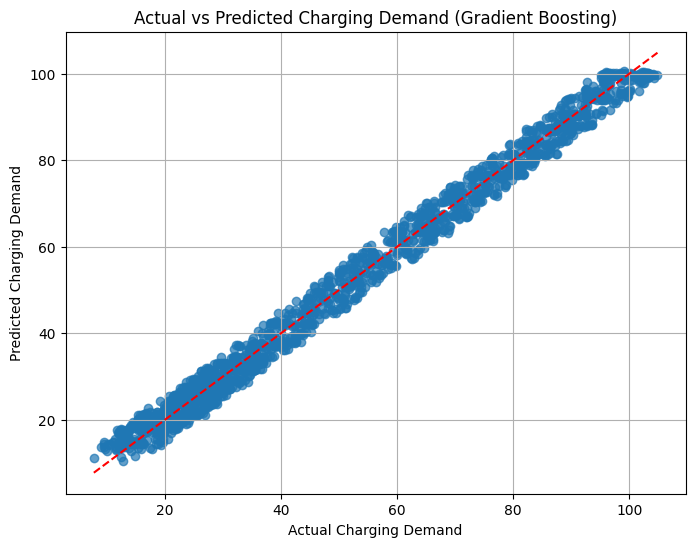

In [39]:
#Visualize Actual vs Predicted Values

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, gb_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel("Actual Charging Demand")
plt.ylabel("Predicted Charging Demand")
plt.title("Actual vs Predicted Charging Demand (Gradient Boosting)")
plt.grid(True)
plt.show()

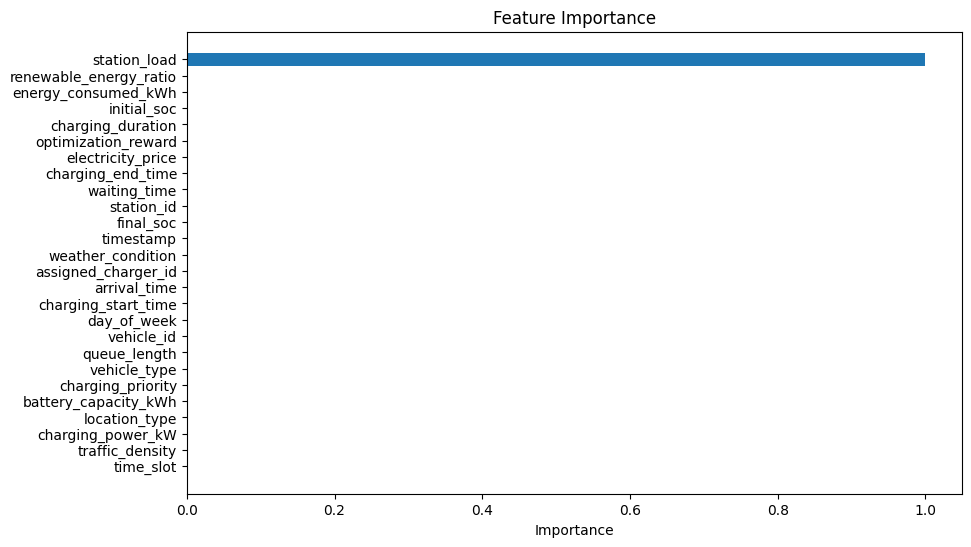

In [31]:
#Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

Prediction System

In [32]:
# This cell defines the raw input data for a new prediction.
# Please provide raw string values for categorical features (e.g., "ST001", "Car")
# and numerical values for numerical features.
# This dictionary will be used by the prediction cell (GKaQ75uTCKMm) for processing.

# To ensure that the LabelEncoders can process the categorical inputs,
# the string values provided for categorical features MUST be present
# in the original training dataset. For demonstration, we'll use values
# from the first row of the original dataset to guarantee valid labels.

import pandas as pd

# First, load the original dataset to extract valid categorical labels for the example
original_data_for_example = pd.read_csv("/content/ev_charging_dataset.csv").iloc[0]

new_raw_input_data = {
    # Categorical features (should be valid strings from original dataset)
    "timestamp": original_data_for_example["timestamp"],
    "station_id": original_data_for_example["station_id"],
    "location_type": original_data_for_example["location_type"],
    "vehicle_id": original_data_for_example["vehicle_id"],
    "vehicle_type": original_data_for_example["vehicle_type"],
    "arrival_time": original_data_for_example["arrival_time"],
    "charging_start_time": original_data_for_example["charging_start_time"],
    "charging_end_time": original_data_for_example["charging_end_time"],
    "traffic_density": original_data_for_example["traffic_density"],
    "weather_condition": original_data_for_example["weather_condition"],
    "day_of_week": original_data_for_example["day_of_week"],
    "time_slot": original_data_for_example["time_slot"],
    "assigned_charger_id": original_data_for_example["assigned_charger_id"],
    "charging_priority": original_data_for_example["charging_priority"],

    # Numerical features (can be any valid numbers)
    "waiting_time": 10,
    "battery_capacity_kWh": 60,
    "initial_soc": 30.0,
    "final_soc": 90.0,
    "energy_consumed_kWh": 35.0,
    "charging_power_kW": 20,
    "charging_duration": 120.0,
    "queue_length": 2,
    "station_load": 50.0,
    "electricity_price": 10.0,
    "renewable_energy_ratio": 0.4,
    "optimization_reward": -5.0
}


In [33]:
import pandas as pd
import numpy as np

# Get the list of columns from the original X DataFrame used for training
X_columns = X.columns.tolist()

# Create a dictionary to hold the single row of new data, ensuring all X columns are present
# and initialized, using values from `new_raw_input_data`.
new_data_dict_aligned = {}

# Ensure `new_raw_input_data` from cell `WeaGLRaHESgJ` is available.
# It should contain a dictionary of raw input values.
if 'new_raw_input_data' not in locals():
    print("Error: `new_raw_input_data` not found. Please run cell `WeaGLRaHESgJ` first.")
else:
    for col in X_columns:
        if col in label_encoders: # If it's a categorical column, use its specific encoder
            # Use the raw string label from `new_raw_input_data`
            raw_label = new_raw_input_data.get(col, None)
            if raw_label is not None:
                try:
                    new_data_dict_aligned[col] = [label_encoders[col].transform([raw_label])[0]]
                except ValueError as e:
                    print(f"Error encoding '{raw_label}' for column '{col}': {e}")
                    # Fallback to a default or raise an error
                    new_data_dict_aligned[col] = [0] # Using 0 as a placeholder, handle appropriately
            else:
                print(f"Warning: Categorical column '{col}' not found in `new_raw_input_data`. Using default 0.")
                new_data_dict_aligned[col] = [0]
        else: # Handle numerical columns
            # Use the numerical value from `new_raw_input_data` or a default
            new_data_dict_aligned[col] = [new_raw_input_data.get(col, 0)] # Default to 0 if not provided

    # Create the new_df_aligned DataFrame
    new_df_aligned = pd.DataFrame(new_data_dict_aligned)

    # Ensure the columns are in the same order as X
    new_df_aligned = new_df_aligned[X_columns]

    # Now scale the aligned new_df
    new_scaled = scaler.transform(new_df_aligned)

    # Use the correct best model, which is `gb`
    prediction = gb.predict(new_scaled)

    print("Predicted Charging Demand:", prediction[0])


Predicted Charging Demand: 51.6977394293905


Save the Model

In [37]:
# Step 10: Save Best Model

import joblib

# Save the trained Gradient Boosting model
joblib.dump(gb, "ev_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature column names
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model Saved Successfully!")
print("Scaler Saved Successfully!")
print("Feature Columns Saved Successfully!")

Model Saved Successfully!
Scaler Saved Successfully!
Feature Columns Saved Successfully!


In [40]:
from google.colab import files

#Download File
files.download("ev_model.pkl")
files.download("scaler.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>